In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

# Base dirs
NEW_DIR = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters")
OLD_DIR = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/output_original/sters")


# Products you care about
products = ["GMFD", "ERA5", "JRA_3Q", "MERRA2"]  # adjust if needed


In [3]:
from sfi import Mata, SFIToolkit

def load_ster_coeffs(ster_path):
    # Load the estimation into Stata memory
    SFIToolkit.execute(f'estimates use "{ster_path}"')

    # pull b vector
    b = Mata.getMatrix("e(b)")
    names = SFIToolkit.getColNames("e(b)")

    import pandas as pd
    df = pd.DataFrame({"parm": names, "beta": b.flatten()})
    return df


ModuleNotFoundError: No module named 'sfi'

In [4]:
from pathlib import Path
import pandas as pd

# Paths you told me
NEW_DIR = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters")
OLD_DIR = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/output_original/sters")

# Where to save comparison tables
OUT_DIR = NEW_DIR / "comparisons"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIR


PosixPath('/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/comparisons')

In [5]:
def load_coeffs(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"{label} file not found: {path}")
    df = pd.read_csv(path)
    if "parm" not in df.columns or "beta" not in df.columns:
        raise ValueError(
            f"{label} file {path} must have columns 'parm' and 'beta'. "
            f"Got: {df.columns.tolist()}"
        )
    return df[["parm", "beta"]].copy()


In [10]:
COMPARISONS = [
    # Uninteracted FGLS: original vs new GMFD
    dict(
        name="FD_FGLS_global_GMFD",
        old=OLD_DIR / "FD_FGLS_global_TINV_clim_coeff.csv",
        new=NEW_DIR / "FD_FGLS_global_GMFD_coeff.csv",
    ),
    # Interacted FGLS: original vs new GMFD
    dict(
        name="FD_FGLS_inter_TINV_clim_GMFD",
        old=OLD_DIR / "FD_FGLS_inter_TINV_clim_quadinter_coeff.csv",  # original
        new=NEW_DIR / "FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv",  # or quadinter if that's what you ran
    ),
]

COMPARISONS


[{'name': 'FD_FGLS_global_GMFD',
  'old': PosixPath('/user/ab5405/summeraliaclimate/code/energy_uncertainty/output_original/sters/FD_FGLS_global_TINV_clim_coeff.csv'),
  'new': PosixPath('/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_global_GMFD_coeff.csv')},
 {'name': 'FD_FGLS_inter_TINV_clim_GMFD',
  'old': PosixPath('/user/ab5405/summeraliaclimate/code/energy_uncertainty/output_original/sters/FD_FGLS_inter_TINV_clim_quadinter_coeff.csv'),
  'new': PosixPath('/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv')}]

In [11]:
def compare_coeff_sets(name: str, old_path: Path, new_path: Path) -> pd.DataFrame:
    print(f"\n=== {name} ===")
    print(f"Old: {old_path}")
    print(f"New: {new_path}")

    old = load_coeffs(old_path, label="old")
    new = load_coeffs(new_path, label="new")

    old = old.rename(columns={"beta": "old_beta"})
    new = new.rename(columns={"beta": "new_beta"})

    # Outer merge so we can see missing / new params too
    comp = old.merge(new, on="parm", how="outer", indicator=True)

    # Differences only make sense when both present
    comp["diff"] = comp["new_beta"] - comp["old_beta"]

    # Relative difference (%), guarding against divide-by-zero
    comp["rel_diff_pct"] = (
        comp["diff"] / comp["old_beta"].abs()
    ) * 100
    comp.loc[comp["old_beta"].isna() | (comp["old_beta"] == 0), "rel_diff_pct"] = pd.NA

    # Quick summary
    both = comp[comp["_merge"] == "both"].dropna(subset=["diff"])
    print(f"  overlapping parameters: {len(both)}")
    if len(both):
        print(f"  max |diff|: {both['diff'].abs().max():.4g}")
        print(f"  max |rel diff| (%): {both['rel_diff_pct'].abs().max():.3f}")
        print(f"  mean |diff|: {both['diff'].abs().mean():.4g}")

    # Save full table
    out_path = OUT_DIR / f"{name}_comparison.csv"
    comp.to_csv(out_path, index=False)
    print(f"  → wrote {out_path}")

    return comp


In [12]:
results = {}

for cfg in COMPARISONS:
    comp_df = compare_coeff_sets(cfg["name"], cfg["old"], cfg["new"])
    results[cfg["name"]] = comp_df



=== FD_FGLS_global_GMFD ===
Old: /user/ab5405/summeraliaclimate/code/energy_uncertainty/output_original/sters/FD_FGLS_global_TINV_clim_coeff.csv
New: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_global_GMFD_coeff.csv
  overlapping parameters: 1
  max |diff|: 0.006167
  max |rel diff| (%): 11.775
  mean |diff|: 0.006167
  → wrote /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/comparisons/FD_FGLS_global_GMFD_comparison.csv

=== FD_FGLS_inter_TINV_clim_GMFD ===
Old: /user/ab5405/summeraliaclimate/code/energy_uncertainty/output_original/sters/FD_FGLS_inter_TINV_clim_quadinter_coeff.csv
New: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv
  overlapping parameters: 33
  max |diff|: 13.21
  max |rel diff| (%): 1035.105
  mean |diff|: 0.5882
  → wrote /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/comparisons/FD_FGLS_

In [13]:
gmfd_unint = results["FD_FGLS_global_GMFD"]

# Parameters sorted by absolute relative difference (largest first)
gmfd_unint.sort_values("rel_diff_pct", key=lambda s: s.abs(), ascending=False).head(20)


,parm,old_beta,new_beta,_merge,diff,rel_diff_pct
0,_cons,5.237862e-02,5.854603e-02,both,0.006167,11.774666
1,c.indp1#c.indf1#c.FD_precip1,NaN,-2.930330e+00,right_only,NaN,NaN
2,c.indp1#c.indf1#c.FD_precip1_GMFD,-2.427724e-05,NaN,left_only,NaN,NaN
3,c.indp1#c.indf1#c.FD_precip2,NaN,7.646465e+02,right_only,NaN,NaN
4,c.indp1#c.indf1#c.FD_precip2_GMFD,1.259008e-07,NaN,left_only,NaN,NaN
5,c.indp1#c.indf1#c.FD_temp1,NaN,2.171204e-05,right_only,NaN,NaN
6,c.indp1#c.indf1#c.FD_temp1_GMFD,1.300003e-05,NaN,left_only,NaN,NaN
7,c.indp1#c.indf1#c.FD_temp2,NaN,-1.213798e-06,right_only,NaN,NaN
8,c.indp1#c.indf1#c.FD_temp2_GMFD,-1.925537e-07,NaN,left_only,NaN,NaN
9,c.indp1#c.indf1#c.FD_temp3,NaN,5.985645e-08,right_only,NaN,NaN


In [14]:
gmfd_int = results["FD_FGLS_inter_TINV_clim_GMFD"]
gmfd_int.sort_values("rel_diff_pct", key=lambda s: s.abs(), ascending=False).head(20)


,parm,old_beta,new_beta,_merge,diff,rel_diff_pct
40,c.indp2#c.indf1#c.FD_dc1_lgdppc_MA15year2I1temp2,6.766200e-12,7.680345e-11,both,7.003725e-11,1035.104541
36,c.indp2#c.indf1#c.FD_dc1_lgdppc_MA15I1temp2,-3.555317e-05,-3.088832e-04,both,-2.733301e-04,-768.792428
7,c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15I1temp1,3.237416e-02,1.473558e-01,both,1.149817e-01,355.164864
2,_cons,-3.986803e-02,5.065687e-02,both,9.052490e-02,227.061369
15,c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15yearI1temp1,-5.019201e-05,-1.599876e-04,both,-1.097955e-04,-218.751044
11,c.indp1#c.indf1#c.FD_dc1_lgdppc_MA15year2I1temp1,1.705784e-08,4.318409e-08,both,2.612625e-08,153.162651
35,c.indp2#c.indf1#c.FD_dc1_lgdppc_MA15I1temp1,-6.152798e-01,-1.284601e+00,both,-6.693211e-01,-108.783220
43,c.indp2#c.indf1#c.FD_dc1_lgdppc_MA15yearI1temp1,6.230056e-04,1.298284e-03,both,6.752780e-04,108.390352
39,c.indp2#c.indf1#c.FD_dc1_lgdppc_MA15year2I1temp1,-1.576049e-07,-3.279533e-07,both,-1.703484e-07,-108.085694
38,c.indp2#c.indf1#c.FD_dc1_lgdppc_MA15I2temp2,-7.043115e-04,-1.396832e-03,both,-6.925208e-04,-98.325930


In [15]:
def normalize_parm(name: str) -> str:
    """
    Put old and new parameter names into a common convention so they can be matched.

    - Strip product suffixes like `_GMFD`, `_ERA5`, `_JRA_3Q`, `_MERRA2`
      when they appear at the *end* of a token (inside the c. ... # ... FD_..._GMFD).
    - You can add more replacements if you see other patterns.
    """
    # strip product suffixes only when they appear immediately before a space or end of string
    for suf in ["_GMFD", "_ERA5", "_JRA_3Q", "_MERRA2"]:
        name = name.replace(suf, "")
    return name


In [16]:
def compare_coeff_sets(name: str, old_path: Path, new_path: Path) -> pd.DataFrame:
    print(f"\n=== {name} ===")
    print(f"Old: {old_path}")
    print(f"New: {new_path}")

    old = load_coeffs(old_path, label="old")
    new = load_coeffs(new_path, label="new")

    old = old.rename(columns={"beta": "old_beta"})
    new = new.rename(columns={"beta": "new_beta"})

    # --- normalize parameter names for merging ---
    old["parm_norm"] = old["parm"].apply(normalize_parm)
    new["parm_norm"] = new["parm"].apply(normalize_parm)

    # Outer merge on normalized name, keep original names for inspection
    comp = old.merge(
        new,
        on="parm_norm",
        how="outer",
        suffixes=("_old", "_new"),
        indicator=True,
    )

    # For readability, move norm + originals up front
    comp = comp[[
        "parm_norm",
        "parm_old", "old_beta",
        "parm_new", "new_beta",
        "_merge",
    ]]

    # Differences only meaningful when both present
    both = comp[comp["_merge"] == "both"].copy()
    both["diff"] = both["new_beta"] - both["old_beta"]
    both["rel_diff_pct"] = (both["diff"] / both["old_beta"].abs()) * 100
    both.loc[both["old_beta"] == 0, "rel_diff_pct"] = pd.NA

    # Put the diff columns back into comp (NaN for non-overlap rows)
    comp = comp.merge(
        both[["parm_norm", "diff", "rel_diff_pct"]],
        on="parm_norm",
        how="left",
    )

    print(f"  overlapping parameters: {both.shape[0]}")
    if both.shape[0]:
        print(f"  max |diff|: {both['diff'].abs().max():.4g}")
        print(f"  max |rel diff| (%): {both['rel_diff_pct'].abs().max():.3f}")
        print(f"  mean |diff|: {both['diff'].abs().mean():.4g}")

    out_path = OUT_DIR / f"{name}_comparison.csv"
    comp.to_csv(out_path, index=False)
    print(f"  → wrote {out_path}")

    return comp


In [17]:
results = {}
for cfg in COMPARISONS:
    comp_df = compare_coeff_sets(cfg["name"], cfg["old"], cfg["new"])
    results[cfg["name"]] = comp_df



=== FD_FGLS_global_GMFD ===
Old: /user/ab5405/summeraliaclimate/code/energy_uncertainty/output_original/sters/FD_FGLS_global_TINV_clim_coeff.csv
New: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_global_GMFD_coeff.csv
  overlapping parameters: 13
  max |diff|: 6833
  max |rel diff| (%): 5446427083779.134
  mean |diff|: 584.7
  → wrote /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/comparisons/FD_FGLS_global_GMFD_comparison.csv

=== FD_FGLS_inter_TINV_clim_GMFD ===
Old: /user/ab5405/summeraliaclimate/code/energy_uncertainty/output_original/sters/FD_FGLS_inter_TINV_clim_quadinter_coeff.csv
New: /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/FD_FGLS_inter_TINV_clim_quadinter_GMFD_coeff.csv
  overlapping parameters: 49
  max |diff|: 943.2
  max |rel diff| (%): 812377336870.699
  mean |diff|: 27.22
  → wrote /user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/comparis

In [18]:
from pathlib import Path
import pandas as pd

# Re-load if needed
OUT_DIR = Path("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/sters/comparisons")

gmfd_unint = pd.read_csv(
    OUT_DIR / "FD_FGLS_global_GMFD_comparison.csv"
)

# Focus only on overlapping parameters
gmfd_unint_both = gmfd_unint[gmfd_unint["_merge"] == "both"].copy()

# Sort by absolute relative difference (descending) to see the worst offenders
gmfd_unint_both.sort_values(
    "rel_diff_pct",
    key=lambda s: s.abs(),
    ascending=False,
    inplace=True,
)

gmfd_unint_both.head(20)


,parm_norm,parm_old,old_beta,parm_new,new_beta,_merge,diff,rel_diff_pct
8,c.indp2#c.indf1#c.FD_precip2,c.indp2#c.indf1#c.FD_precip2_GMFD,1.254667e-07,c.indp2#c.indf1#c.FD_precip2,-6.833450e+03,both,-6.833450e+03,-5.446427e+12
2,c.indp1#c.indf1#c.FD_precip2,c.indp1#c.indf1#c.FD_precip2_GMFD,1.259008e-07,c.indp1#c.indf1#c.FD_precip2,7.646465e+02,both,7.646465e+02,6.073405e+11
1,c.indp1#c.indf1#c.FD_precip1,c.indp1#c.indf1#c.FD_precip1_GMFD,-2.427724e-05,c.indp1#c.indf1#c.FD_precip1,-2.930330e+00,both,-2.930305e+00,-1.207018e+07
7,c.indp2#c.indf1#c.FD_precip1,c.indp2#c.indf1#c.FD_precip1_GMFD,-1.183683e-04,c.indp2#c.indf1#c.FD_precip1,-1.716937e-02,both,-1.705100e-02,-1.440505e+04
4,c.indp1#c.indf1#c.FD_temp2,c.indp1#c.indf1#c.FD_temp2_GMFD,-1.925537e-07,c.indp1#c.indf1#c.FD_temp2,-1.213798e-06,both,-1.021244e-06,-5.303684e+02
10,c.indp2#c.indf1#c.FD_temp2,c.indp2#c.indf1#c.FD_temp2_GMFD,6.707160e-06,c.indp2#c.indf1#c.FD_temp2,8.399001e-07,both,-5.867260e-06,-8.747756e+01
3,c.indp1#c.indf1#c.FD_temp1,c.indp1#c.indf1#c.FD_temp1_GMFD,1.300003e-05,c.indp1#c.indf1#c.FD_temp1,2.171204e-05,both,8.712016e-06,6.701537e+01
5,c.indp1#c.indf1#c.FD_temp3,c.indp1#c.indf1#c.FD_temp3_GMFD,3.802910e-08,c.indp1#c.indf1#c.FD_temp3,5.985645e-08,both,2.182735e-08,5.739645e+01
11,c.indp2#c.indf1#c.FD_temp3,c.indp2#c.indf1#c.FD_temp3_GMFD,1.187435e-06,c.indp2#c.indf1#c.FD_temp3,1.377767e-06,both,1.903315e-07,1.602879e+01
12,c.indp2#c.indf1#c.FD_temp4,c.indp2#c.indf1#c.FD_temp4_GMFD,-2.479861e-08,c.indp2#c.indf1#c.FD_temp4,-2.834101e-08,both,-3.542395e-09,-1.428465e+01


In [19]:
gmfd_unint = results["FD_FGLS_global_GMFD"]
gmfd_unint[gmfd_unint["_merge"] == "both"] \
    .sort_values("rel_diff_pct", key=lambda s: s.abs(), ascending=False) \
    .head(20)


,parm_norm,parm_old,old_beta,parm_new,new_beta,_merge,diff,rel_diff_pct
8,c.indp2#c.indf1#c.FD_precip2,c.indp2#c.indf1#c.FD_precip2_GMFD,1.254667e-07,c.indp2#c.indf1#c.FD_precip2,-6.833450e+03,both,-6.833450e+03,-5.446427e+12
2,c.indp1#c.indf1#c.FD_precip2,c.indp1#c.indf1#c.FD_precip2_GMFD,1.259008e-07,c.indp1#c.indf1#c.FD_precip2,7.646465e+02,both,7.646465e+02,6.073405e+11
1,c.indp1#c.indf1#c.FD_precip1,c.indp1#c.indf1#c.FD_precip1_GMFD,-2.427724e-05,c.indp1#c.indf1#c.FD_precip1,-2.930330e+00,both,-2.930305e+00,-1.207018e+07
7,c.indp2#c.indf1#c.FD_precip1,c.indp2#c.indf1#c.FD_precip1_GMFD,-1.183683e-04,c.indp2#c.indf1#c.FD_precip1,-1.716937e-02,both,-1.705100e-02,-1.440505e+04
4,c.indp1#c.indf1#c.FD_temp2,c.indp1#c.indf1#c.FD_temp2_GMFD,-1.925537e-07,c.indp1#c.indf1#c.FD_temp2,-1.213798e-06,both,-1.021244e-06,-5.303684e+02
10,c.indp2#c.indf1#c.FD_temp2,c.indp2#c.indf1#c.FD_temp2_GMFD,6.707160e-06,c.indp2#c.indf1#c.FD_temp2,8.399001e-07,both,-5.867260e-06,-8.747756e+01
3,c.indp1#c.indf1#c.FD_temp1,c.indp1#c.indf1#c.FD_temp1_GMFD,1.300003e-05,c.indp1#c.indf1#c.FD_temp1,2.171204e-05,both,8.712016e-06,6.701537e+01
5,c.indp1#c.indf1#c.FD_temp3,c.indp1#c.indf1#c.FD_temp3_GMFD,3.802910e-08,c.indp1#c.indf1#c.FD_temp3,5.985645e-08,both,2.182735e-08,5.739645e+01
11,c.indp2#c.indf1#c.FD_temp3,c.indp2#c.indf1#c.FD_temp3_GMFD,1.187435e-06,c.indp2#c.indf1#c.FD_temp3,1.377767e-06,both,1.903315e-07,1.602879e+01
12,c.indp2#c.indf1#c.FD_temp4,c.indp2#c.indf1#c.FD_temp4_GMFD,-2.479861e-08,c.indp2#c.indf1#c.FD_temp4,-2.834101e-08,both,-3.542395e-09,-1.428465e+01


In [20]:
# Temp-only coefficients
mask_temp = gmfd_unint_both["parm_norm"].str.contains("FD_temp")
gmfd_unint_temp = gmfd_unint_both[mask_temp].copy()

gmfd_unint_temp[["parm_norm", "old_beta", "new_beta", "diff", "rel_diff_pct"]]


,parm_norm,old_beta,new_beta,diff,rel_diff_pct
4,c.indp1#c.indf1#c.FD_temp2,-1.925537e-07,-1.213798e-06,-1.021244e-06,-530.368446
10,c.indp2#c.indf1#c.FD_temp2,6.707160e-06,8.399001e-07,-5.867260e-06,-87.477560
3,c.indp1#c.indf1#c.FD_temp1,1.300003e-05,2.171204e-05,8.712016e-06,67.015374
5,c.indp1#c.indf1#c.FD_temp3,3.802910e-08,5.985645e-08,2.182735e-08,57.396445
11,c.indp2#c.indf1#c.FD_temp3,1.187435e-06,1.377767e-06,1.903315e-07,16.028792
12,c.indp2#c.indf1#c.FD_temp4,-2.479861e-08,-2.834101e-08,-3.542395e-09,-14.284648
9,c.indp2#c.indf1#c.FD_temp1,-8.855027e-04,-7.692260e-04,1.162768e-04,13.131157
6,c.indp1#c.indf1#c.FD_temp4,-1.139332e-09,-1.076671e-09,6.266151e-11,5.499846


In [21]:
mask_precip = gmfd_unint_both["parm_norm"].str.contains("FD_precip")
gmfd_unint_precip = gmfd_unint_both[mask_precip].copy()

gmfd_unint_precip[["parm_norm", "old_beta", "new_beta", "diff", "rel_diff_pct"]]


,parm_norm,old_beta,new_beta,diff,rel_diff_pct
8,c.indp2#c.indf1#c.FD_precip2,1.254667e-07,-6833.449614,-6833.449614,-5.446427e+12
2,c.indp1#c.indf1#c.FD_precip2,1.259008e-07,764.646499,764.646499,6.073405e+11
1,c.indp1#c.indf1#c.FD_precip1,-2.427724e-05,-2.930330,-2.930305,-1.207018e+07
7,c.indp2#c.indf1#c.FD_precip1,-1.183683e-04,-0.017169,-0.017051,-1.440505e+04


In [22]:
product = ["JRA-3Q"]
car_paths_path = ("/user/ab5405/summeraliaclimate/code/regressions/0_generate_obs_data/car_paths.csv")
print("[INFO] Reading", car_paths_path)
car_paths = pd.read_csv(car_paths_path)
car_paths = car_paths.dropna(subset=["product"])

[INFO] Reading /user/ab5405/summeraliaclimate/code/regressions/0_generate_obs_data/car_paths.csv


In [23]:
for _, row in car_paths.iterrows():
        product_label = str(row["product"]).strip()

        if product_label != "MERRA2":
            continue

        tas_path = Path(str(row["tas_filepath"]).strip())
        precip_raw = row.get("precip_filepath", None)
        precip_path = (
            Path(precip_raw.strip())
            if isinstance(precip_raw, str) and precip_raw.strip() != ""
            else None
        )

In [24]:
import xarray as xr
def open_any(path: Path) -> xr.Dataset:
    path = Path(path)
    if path.suffix == ".zarr":
        return xr.open_zarr(path, consolidated=False)
    return xr.open_dataset(path, chunks={"lat": -1, "lon": -1, "time": 20})


In [25]:
ds = open_any(precip_path)

/tmp/8444720.1.debian.q/ipykernel_42009/2681203044.py:6: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 20. This could degrade performance. Instead, consider rechunking after loading.
  return xr.open_dataset(path, chunks={"lat": -1, "lon": -1, "time": 20})


In [26]:
ds['pr']

<xarray.DataArray 'pr' (time: 545, lat: 361, lon: 576)> Size: 453MB
dask.array<open_dataset-pr, shape=(545, 361, 576), dtype=float32, chunksize=(20, 361, 576), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 4kB 1980-01-01 1980-02-01 ... 2025-05-01
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
Attributes:
    long_name:       total_precipitation
    units:           kg m-2 s-1
    fmissing_value:  1000000000000000.0
    vmax:            1000000000000000.0
    vmin:            -1000000000000000.0

In [27]:
ds = xr.open_zarr("/shared/share_hle/data/climate_raw/GMFD/pr_Amon_GMFD_historical_reanalysis_19810131-20101231.zarr")
print(ds.time.values[:5])
print(ds["pr"].attrs)


['1981-01-31T00:00:00.000000000' '1981-02-28T00:00:00.000000000'
 '1981-03-31T00:00:00.000000000' '1981-04-30T00:00:00.000000000'
 '1981-05-31T00:00:00.000000000']
{'source': 'Reanalysis daily precipitation corrected for spurious rain day frequencies, downscaled in space to 1.0deg and time to 3-hourly, scaled to match the CRU TS3.0 monthly dataset', 'name': 'prcp', 'title': 'daily bias corrected precipitation', 'date': '01/01/81', 'time': '00:00', 'long_name': 'Precipitation', 'units': 'kg m-2 s-1', 'valid_min': 0.0, 'valid_max': 0.007638025563210249}


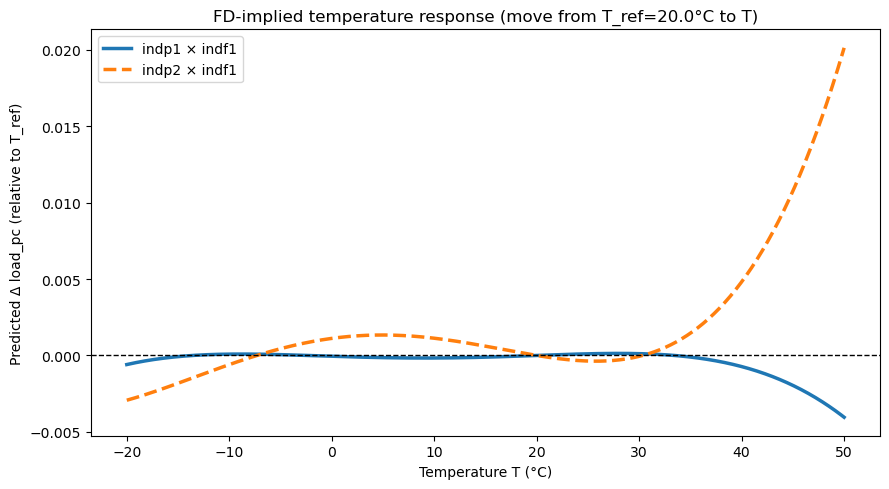

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def fd_response_curve(T, beta, T_ref=20.0):
    """
    beta: dict with keys temp1..temp4 (coefficients on FD_temp1..FD_temp4)
    Returns: Δŷ(T; T_ref) = Σ_k beta_k (T^k - T_ref^k)
    """
    T = np.asarray(T)
    out = np.zeros_like(T, dtype=float)
    for k in [1,2,3,4]:
        out += beta[f"temp{k}"] * (T**k - T_ref**k)
    return out

# Example: build beta dict from the lines you pasted (indp1 × indf1)
beta_indp1 = {
    "temp1": -2.19003455725e-05,
    "temp2":  3.64468961372e-07,
    "temp3":  9.19202657032e-08,
    "temp4": -2.44748393243e-09,
}

beta_indp2 = {
    "temp1":  9.06211473126e-05,
    "temp2": -9.19759663766e-06,
    "temp3": -4.35183061007e-08,
    "temp4":  6.86586414670e-09,
}

T = np.linspace(-20, 50, 800)
T_ref = 20.0

y1 = fd_response_curve(T, beta_indp1, T_ref=T_ref)
y2 = fd_response_curve(T, beta_indp2, T_ref=T_ref)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(T, y1, lw=2.5, label="indp1 × indf1")
ax.plot(T, y2, lw=2.5, ls="--", label="indp2 × indf1")
ax.axhline(0, color="k", lw=1, ls="--")
ax.set_xlabel("Temperature T (°C)")
ax.set_ylabel("Predicted Δ load_pc (relative to T_ref)")
ax.set_title(f"FD-implied temperature response (move from T_ref={T_ref}°C to T)")
ax.legend()
plt.tight_layout()
plt.show()


In [38]:
import xarray as xr
from pathlib import Path

p = Path("/shared/share_hle/data/climate_raw/GMFD/pr_Amon_GMFD_historical_reanalysis_19810131-20101231.zarr")

ds = xr.open_zarr(p, consolidated=False)

print("data vars:", list(ds.data_vars))
print("coords:", list(ds.coords))

pr = ds["pr"]
print("pr attrs:", pr.attrs)

# global mean of first timestep (over lat/lon); skip NaNs
print("t0 global mean:", float(pr.isel(time=0).mean(skipna=True).values))


data vars: ['pr']
coords: ['lat', 'lon', 'time']
pr attrs: {'source': 'Reanalysis daily precipitation corrected for spurious rain day frequencies, downscaled in space to 1.0deg and time to 3-hourly, scaled to match the CRU TS3.0 monthly dataset', 'name': 'prcp', 'title': 'daily bias corrected precipitation', 'date': '01/01/81', 'time': '00:00', 'long_name': 'Precipitation', 'units': 'kg m-2 s-1', 'valid_min': 0.0, 'valid_max': 0.007638025563210249}
t0 global mean: 2.0370251149870455e-05


In [39]:
# show min/max too
t0 = pr.isel(time=0)
print("t0 min/max:", float(t0.min(skipna=True).values), float(t0.max(skipna=True).values))

# if units are flux, this should look “small” (order 1e-6 to 1e-4)
# if units are already mm/month, it’ll look “human-scale” (order 10–200+)


t0 min/max: 0.0 0.0007280110148712993


In [40]:
pr = ds["pr"].sel(time=slice("1981-01-01","1981-12-31"))
pr_mm_month = pr * 86400.0 * pr["time"].dt.days_in_month
pr_annual = pr_mm_month.sum("time")
print(float(pr_annual.mean(skipna=True).values))


669.8180965561425


In [42]:
import pandas as pd

path = "/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/country_climate/GMFD/GMFD_country_year_1971_2010.csv"
df = pd.read_csv(path)

df[["precip1_GMFD", "precip2_GMFD"]].describe()


,precip1_GMFD,precip2_GMFD
count,7410.000000,7.410000e+03
mean,1265.668060,2.468804e+06
std,931.131216,4.601786e+06
min,7.144874,5.104923e+01
25%,598.308478,3.579730e+05
50%,1050.294614,1.103119e+06
75%,1752.358836,3.070761e+06
max,9908.519734,9.817876e+07


In [44]:
import pandas as pd

df = pd.read_stata("/user/ab5405/summeraliaclimate/code/energy_uncertainty/data/regression/GMFD_TINV_clim_regsort.dta")

# Find precip-like columns
[c for c in df.columns if "precip" in c.lower()]


['precip2_other_GMFD',
 'precip1_other_GMFD',
 'precip1_GMFD',
 'precip2_GMFD',
 'FD_precip1',
 'FD_precip2']

In [45]:
df[[c for c in df.columns if "precip" in c.lower()]].describe()


,precip2_other_GMFD,precip1_other_GMFD,precip1_GMFD,precip2_GMFD,FD_precip1,FD_precip2
count,8221.000000,8221.000000,6535.000000,6.535000e+03,5960.000000,5.960000e+03
mean,45757.480996,1091.671142,0.012472,5.872046e-06,0.000034,-3.396042e-08
std,55752.536916,740.723047,0.008618,7.427028e-06,0.003110,5.783155e-06
min,13.711803,6.573801,0.000085,2.141726e-09,-0.020443,-7.620069e-05
25%,11569.957818,534.469337,0.005996,1.439666e-06,-0.001226,-8.767859e-07
50%,29632.986191,946.034542,0.010849,3.705325e-06,0.000030,1.721030e-08
75%,57395.046062,1518.695403,0.017366,7.444251e-06,0.001308,9.409614e-07
max,635134.107609,4289.934940,0.049858,9.447667e-05,0.017400,6.952353e-05
